Figure S12: Height colocalization for a HOXB cluster pcQTL. A Credible set group graph for the cluster. B QTL nominal p-values for each gene’s expression and each PC vs genomic position. If the phenotype has any significant credible sets, a plot is shown for each credible set, with credible set variants highlighted and colors given by variant LD with the credible-set lead variant. C GWAS variant nominal p-values vs QTL nominal p-values for each gene’s expression and each PC. If the phenotype has any significant credible sets, a plot is shown for each credible set with the credible set variants highlighted and the highest PPH4 (probability of colocalization) is given between QTL credible set and any GWAS credible sets.

Using Python: /home/klawren/.pixi/envs/python/bin/python


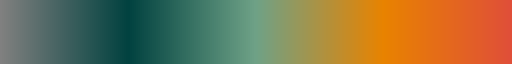

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
import upsetplot as up
from scipy.stats import ttest_ind
from matplotlib.colors import LinearSegmentedColormap
import ast
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
import matplotlib as mpl
import math


from tqdm.auto import tqdm 
tqdm.pandas()

prefix = '/home/klawren/oak/pcqtls'
import yaml
config_path= f'{prefix}/config_old/main_pcqtl.yaml'
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

import sys
sys.path.append(f'{config["working_dir"]}/{config["code_dir"]}')
from utils import *
from group_signals import load_gwas_coloc


%config InlineBackend.figure_formats = ['png']

plt.rcParams.update({
    'font.size': 8,           # Base font size
    'axes.labelsize': 9,      # Axis labels
    'axes.titlesize': 10,     # Subplot titles
    'xtick.labelsize': 8,     # X-axis tick labels
    'ytick.labelsize': 8,     # Y-axis tick labels
    'legend.fontsize': 8,     # Legend
    'pdf.fonttype': 42,       # Embed fonts in PDF
    'ps.fonttype': 42,        # Embed fonts in PS
})

qtl_palette = {'pcQTL only':'#62005A', 'eQTL only':'#6FA287', 'Both':'#007C92', 'Neither':'grey'}

ld_palette = LinearSegmentedColormap.from_list(
    "darkblue_green_yellow_red",
    ["grey", "#014240", "#6FA287", "#E98300", "#E04F39"]
)
ld_norm = mpl.colors.Normalize(vmin=0, vmax=1)

ld_palette


In [39]:
example_signal_id = 'ENSG00000108511.9_ENSG00000120068.6_ENSG00000120075.5_ENSG00000120093.11_ENSG00000182742.5_ENSG00000260027.4_pc4_cs_2-gwas_GIANT_HEIGHT_cluster_ENSG00000108511.9_ENSG00000120068.6_ENSG00000120075.5_ENSG00000120093.11_ENSG00000182742.5_ENSG00000260027.4_cs_5'
example_cluster_id = 'ENSG00000108511.9_ENSG00000120068.6_ENSG00000120075.5_ENSG00000120093.11_ENSG00000182742.5_ENSG00000260027.4'
example_tissue_id = 'Esophagus_Muscularis'
example_cs_id = 'ENSG00000108511.9_ENSG00000120068.6_ENSG00000120075.5_ENSG00000120093.11_ENSG00000182742.5_ENSG00000260027.4_pc4_cs_2'
example_gwas_id = 'GIANT_HEIGHT_cs_5_cluster_ENSG00000108511.9_ENSG00000120068.6_ENSG00000120075.5_ENSG00000120093.11_ENSG00000182742.5_ENSG00000260027.4'
example_lead_variant_id = 'chr17_48584210_C_T_b38'
example_gwas_traits = ["GIANT_HEIGHT"]
gwas_names = ['Height']

In [40]:
susie_annotated = load_susie_annotated(config, example_tissue_id)
gwas_signals = load_across_tissues(config, load_gwas_signal_groups)

In [41]:
example_coloc = gwas_signals[gwas_signals['signal_id'] == example_signal_id].iloc[0]
example_cs = susie_annotated[susie_annotated['cs_id'] == example_cs_id]
example_var = example_cs.iloc[0]
example_lead_variant_id = example_cs[example_cs['pip'] == example_cs['pip'].max()]['variant_id'].iloc[0]
example_lead_variant_id

'chr17_48584210_C_T_b38'

In [42]:
# bring in the nominal p values
nominal_e = load_e_nominal(config, example_var['tissue_id'], example_var['chr'])
nominal_pc = load_pc_nominal(config, example_var['tissue_id'], example_var['chr'])

In [43]:
# bring in gwas summary stats
gwas_data = []
for example_gwas_trait in example_gwas_traits:
    gwas_path = f'/oak/stanford/groups/smontgom/shared/gwas_summary_stats/barbeira_gtex_imputed/imputed_gwas_hg38_1.1/imputed_{example_gwas_trait}.txt.gz'
    example_gwas = pd.read_csv(gwas_path, sep='\t')
    gwas_data.append(example_gwas)

In [44]:
# subset the nomal p values
nominal_e = nominal_e[(nominal_e['cluster_id'] == example_coloc['cluster_id'])]
nominal_pc = nominal_pc[(nominal_pc['cluster_id'] == example_coloc['cluster_id'])]
for i in range(len(gwas_data)):
    gwas_data[i] = gwas_data[i][gwas_data[i]['panel_variant_id'].isin(nominal_e['variant_id'])]

In [45]:
# load in ld
ld_path = f'{config["working_dir"]}/{config["coloc_output_dir"]}/temp/ld/{example_cluster_id}.ld'
ld = pd.read_table(ld_path, sep='\t', header=None)
snp_list_path = f'{config["working_dir"]}/{config["coloc_output_dir"]}/temp/ld/{example_cluster_id}.snp_list.txt'
snps = pd.read_table(snp_list_path, header=None)
ld.columns = snps[0].values
ld.index = snps[0].values

In [46]:
# load in individual gwas coloc results 
gwas_coloc = []
for gwas_trait in example_gwas_traits:
    gwas_path = f'{config["working_dir"]}/{config["coloc_output_dir"]}gwas_susie_True/{example_tissue_id}/{example_tissue_id}.v8.{gwas_trait}.gwas_coloc.txt'
    gwas_coloc.append(pd.read_csv(gwas_path, sep='\t'))

gwas_coloc = pd.concat(gwas_coloc)

In [47]:
def plot_egene_coloc(ax, gene_name, example_egene_id, nominal_e, example_gwas, gwas_name, plot_egene_cs=True, plot_example_cs=True):
    egene_pvalues = nominal_e[(nominal_e['egene_id']==example_egene_id)][['variant_id', 'pval_nominal']]
    gwas_egene_pvalues_merged = pd.merge(egene_pvalues, example_gwas[['panel_variant_id', 'pvalue']], left_on='variant_id', right_on='panel_variant_id', how='inner')

    sns.scatterplot(gwas_egene_pvalues_merged, x='pval_nominal', y='pvalue', s=2, alpha=1, edgecolor=None, ax=ax, color='grey', legend=False)

    if plot_example_cs:
        example_cs_lead_variant_id = example_cs[example_cs['pip'] == example_cs['pip'].max()]['variant_id'].iloc[0]
        sns.scatterplot(gwas_egene_pvalues_merged[gwas_egene_pvalues_merged['variant_id'].isin(example_cs['variant_id'])], x='pval_nominal', y='pvalue', s=40*example_cs['pip'], alpha=1, linewidth=1, edgecolor='k', ax=ax, color='#417865', legend=False)
        sns.scatterplot(gwas_egene_pvalues_merged[gwas_egene_pvalues_merged['variant_id'].isin([example_cs_lead_variant_id])], x='pval_nominal', y='pvalue', s=40, alpha=1, linewidth=1, edgecolor='k', ax=ax, color='#417865', marker='D', legend=False)

    if plot_egene_cs:
        egene_cs = susie_annotated[susie_annotated['phenotype_id'] == example_cluster_id + '_e_' + example_egene_id]
        if len(egene_cs) > 0:
            egene_cs_lead_variant_id = egene_cs.groupby('cs_id').apply(lambda x: x[x['pip'] == x['pip'].max()]['variant_id'].iloc[0]).reset_index(name='variant_id')['variant_id'].values
            sns.scatterplot(gwas_egene_pvalues_merged[gwas_egene_pvalues_merged['variant_id'].isin(egene_cs['variant_id'])], x='pval_nominal', y='pvalue', s=20, alpha=1, linewidth=1, ax=ax, edgecolor='k', color='#417865', legend=False)
            sns.scatterplot(gwas_egene_pvalues_merged[gwas_egene_pvalues_merged['variant_id'].isin(egene_cs_lead_variant_id)], x='pval_nominal', y='pvalue', s=40, alpha=1, linewidth=1, edgecolor='k', ax=ax, color='#417865', marker='D', legend=False)
 
    ax.invert_xaxis()
    ax.invert_yaxis()
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.spines[['right', 'top']].set_visible(False)
    ax.set_xlabel(f'{gene_name} eQTL p-value')
    ax.set_ylabel(f'{gwas_name} GWAS p-value')
    # ax.set_xticks([1e0, 1e-6, 1e-12])
    # ax.set_yticks([1e0, 1e-6, 1e-12])
    return ax

In [48]:
def plot_pcgene_coloc(ax, example_pc_num, nominal_pc, example_gwas, gwas_name, plot_example_cs=True, plot_pc_cs=True):
    pc_pvalues = nominal_pc[(nominal_pc['pc_num']==example_pc_num)][['variant_id', 'pval_nominal']]
    gwas_pc_pvalues_merged = pd.merge(pc_pvalues, example_gwas[['panel_variant_id', 'pvalue']], left_on='variant_id', right_on='panel_variant_id', how='inner')

    sns.scatterplot(gwas_pc_pvalues_merged, x='pval_nominal', y='pvalue', s=2, alpha=1, edgecolor=None, ax=ax, color='grey', legend=False)

    if plot_example_cs:
        sns.scatterplot(gwas_pc_pvalues_merged[gwas_pc_pvalues_merged['variant_id'].isin(example_cs['variant_id'])], x='pval_nominal', y='pvalue', s=20, alpha=1, linewidth=1, edgecolor='k', ax=ax, color='#62005A', legend=False)
        example_cs_lead_variant_id = example_cs[example_cs['pip'] == example_cs['pip'].max()]['variant_id'].iloc[0]
        sns.scatterplot(gwas_pc_pvalues_merged[gwas_pc_pvalues_merged['variant_id'].isin([example_cs_lead_variant_id])], x='pval_nominal', y='pvalue', s=40, alpha=1, linewidth=1, edgecolor='k', ax=ax, color='#62005A', marker='D', legend=False)

    if plot_pc_cs:
        pc_cs = susie_annotated[susie_annotated['phenotype_id'] == example_cluster_id + '_pc' + str(example_pc_num)]
        if len(pc_cs) > 0:
            pc_cs_lead_variant_id = pc_cs.groupby('cs_id').apply(lambda x: x[x['pip'] == x['pip'].max()]['variant_id'].iloc[0]).reset_index(name='variant_id')['variant_id'].values
            sns.scatterplot(gwas_pc_pvalues_merged[gwas_pc_pvalues_merged['variant_id'].isin(pc_cs['variant_id'])], x='pval_nominal', y='pvalue', s=20, alpha=1, linewidth=1, edgecolor='k', ax=ax, color='#62005A', legend=False)
            pc_cs_lead_variant_id = pc_cs[pc_cs['pip'] == pc_cs['pip'].max()]['variant_id'].iloc[0]
            sns.scatterplot(gwas_pc_pvalues_merged[gwas_pc_pvalues_merged['variant_id'].isin([pc_cs_lead_variant_id])], x='pval_nominal', y='pvalue', s=40, alpha=1, linewidth=1, ax=ax, edgecolor='k', color='#62005A', marker='D', legend=False)

    ax.invert_xaxis()
    ax.invert_yaxis()
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.spines[['right', 'top']].set_visible(False)
    ax.set_xlabel(f'PC{example_pc_num} p-value')
    ax.set_ylabel(f'{gwas_name} p-value')
    # ax.set_xticks([1e0, 1e-6, 1e-12])
    # ax.set_yticks([1e0, 1e-6, 1e-12])
    return ax

In [49]:
# cluster coloc graph
coloc_cutoff = 0.75
pair_coloc_qtl = load_pairwise_coloc(config, example_tissue_id)

# get the gwas-qtl coloc pairs
cluster_gwas_pairs = gwas_coloc[(gwas_coloc['qtl_id'].str.contains(example_cluster_id))]
cluster_gwas_pairs['id1_short'] = np.where(cluster_gwas_pairs['qtl_id'].str.contains('_e_'), cluster_gwas_pairs['qtl_id'].str.split('_e_').str[-1], 'PC' + cluster_gwas_pairs['qtl_id'].str.split('_pc').str[-1])
cluster_gwas_pairs['id2_short'] = 'gwas-' + cluster_gwas_pairs['gwas_id'] + '\ncs' + cluster_gwas_pairs['idx1'].astype(str)
cluster_gwas_pairs['id1_short'] = cluster_gwas_pairs['id1_short'].apply(get_gene_name, config=config) + '\ncs' + cluster_gwas_pairs['qtl_cs_is'].astype(int).astype(str)
# drop out GWAS that don't coloc with anything
gwas_max_pph4 = cluster_gwas_pairs.groupby('idx1').agg({'PP.H4.abf':'max'})
cluster_gwas_pairs = cluster_gwas_pairs[cluster_gwas_pairs['idx1'].isin(gwas_max_pph4[gwas_max_pph4['PP.H4.abf'] > coloc_cutoff].index.values)]

# load in the pair qlt-qtl colocs too
pair_coloc_qtl['cluster_id'] = pair_coloc_qtl['qtl1_id'].str.split('_e_').str[0].str.split('_pc').str[0]
cluster_pairs_qtl = pair_coloc_qtl[pair_coloc_qtl['cluster_id'] == example_cluster_id]
cluster_pairs_qtl['id1_short'] = np.where(cluster_pairs_qtl['qtl1_id'].str.contains('_e_'), cluster_pairs_qtl['qtl1_id'].str.split('_e_').str[-1], 'PC' + cluster_pairs_qtl['qtl1_id'].str.split('_pc').str[-1])
cluster_pairs_qtl['id2_short'] = np.where(cluster_pairs_qtl['qtl2_id'].str.contains('_e_'), cluster_pairs_qtl['qtl2_id'].str.split('_e_').str[-1], 'PC' + cluster_pairs_qtl['qtl2_id'].str.split('_pc').str[-1])
cluster_pairs_qtl['id1_short'] = cluster_pairs_qtl['id1_short'].apply(get_gene_name, config=config) + '\ncs' + cluster_pairs_qtl['idx1'].astype(str)
cluster_pairs_qtl['id2_short'] = cluster_pairs_qtl['id2_short'].apply(get_gene_name, config=config)+ '\ncs' + cluster_pairs_qtl['idx2'].astype(str)


/local/scratch/klawren/slrmtmp.48776383/ipykernel_28379/2906043469.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_gwas_pairs['id1_short'] = np.where(cluster_gwas_pairs['qtl_id'].str.contains('_e_'), cluster_gwas_pairs['qtl_id'].str.split('_e_').str[-1], 'PC' + cluster_gwas_pairs['qtl_id'].str.split('_pc').str[-1])
/local/scratch/klawren/slrmtmp.48776383/ipykernel_28379/2906043469.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_gwas_pairs['id2_short'] = 'gwas-' + cluster_gwas_pairs['

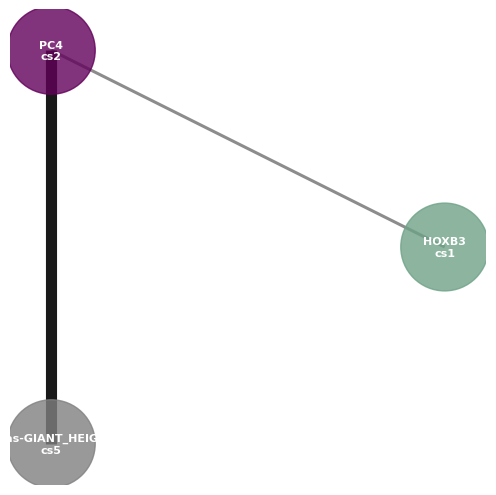

In [50]:
# Create an undirected graph
G = nx.Graph()

# Add edges to the graph with weights
for index, row in pd.concat([cluster_pairs_qtl, cluster_gwas_pairs]).iterrows():
    G.add_edge(row['id1_short'], row['id2_short'], weight=row['PP.H4.abf'])

# Get edge weights for thickness
edge_weights = [G[u][v]['weight']*8 for u, v in G.edges()]
edge_colors = ['k' if G[u][v]['weight'] > 0.75 else 'gray' for u, v in G.edges()]
node_colors = [qtl_palette['Neither'] if 'gwas' in node else qtl_palette['pcQTL only'] if 'PC' in node else qtl_palette['eQTL only'] for node in G.nodes()]

fig, ax = plt.subplots(figsize=(5, 5)) 

# Use a rescaled circular layout to prevent nodes from running off the edge
pos = nx.circular_layout(G)
nx.draw_networkx_nodes(G, pos, node_size=4000, node_color=node_colors, alpha=.8, ax=ax)
nx.draw_networkx_edges(G, pos, width=edge_weights, edge_color=edge_colors, alpha=.9, ax=ax)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8, font_color='white', font_weight='bold')
ax.axis('off')  # Turn off the axis

plt.tight_layout()
plt.savefig(f"{config['working_dir']}/workflow/supplemental_figures/figures/figure_s12_a.pdf", 
            transparent=True, bbox_inches='tight', dpi=300)

plt.show()

In [51]:
# afc information 
pcqtl_afc = load_across_tissues(config, load_pc_afc)
susie_annotated['gene_id'] = susie_annotated['cluster_id'].str.split('_')
susie_explode = susie_annotated.explode('gene_id')

# merge in afc information
susie_explode_afc = pd.merge(susie_explode, pcqtl_afc[['pid', 'sid', 'tissue_id', 'log2_aFC']], left_on=['gene_id', 'variant_id', 'tissue_id'], 
    right_on=['pid', 'sid', 'tissue_id'], how='left')

# pip-weighted afc over credible set
susie_explode_afc['pip_afc'] = susie_explode_afc['pip'] * susie_explode_afc['log2_aFC']
credible_set_grouped_afc = susie_explode_afc.groupby(['phenotype_id', 'cs_id', 'tissue_id', 'gene_id']).agg({'pip_afc':'sum', 'pip':'sum'}).reset_index()
credible_set_grouped_afc['pip_afc_weighted'] = credible_set_grouped_afc['pip_afc']/credible_set_grouped_afc['pip']
credible_set_grouped_afc['abs_pip_afc_weighted'] = credible_set_grouped_afc['pip_afc_weighted'].abs()
credible_set_grouped_afc[credible_set_grouped_afc['phenotype_id'].str.contains(example_cluster_id)]

,phenotype_id,cs_id,tissue_id,gene_id,pip_afc,pip,pip_afc_weighted,abs_pip_afc_weighted
1586,ENSG00000108511.9_ENSG00000120068.6_ENSG000001...,ENSG00000108511.9_ENSG00000120068.6_ENSG000001...,Esophagus_Muscularis,ENSG00000108511.9,0.000000,0.984430,0.000000,0.000000
1587,ENSG00000108511.9_ENSG00000120068.6_ENSG000001...,ENSG00000108511.9_ENSG00000120068.6_ENSG000001...,Esophagus_Muscularis,ENSG00000120068.6,0.000000,0.984430,0.000000,0.000000
1588,ENSG00000108511.9_ENSG00000120068.6_ENSG000001...,ENSG00000108511.9_ENSG00000120068.6_ENSG000001...,Esophagus_Muscularis,ENSG00000120075.5,0.000000,0.984430,0.000000,0.000000
1589,ENSG00000108511.9_ENSG00000120068.6_ENSG000001...,ENSG00000108511.9_ENSG00000120068.6_ENSG000001...,Esophagus_Muscularis,ENSG00000120093.11,0.000000,0.984430,0.000000,0.000000
1590,ENSG00000108511.9_ENSG00000120068.6_ENSG000001...,ENSG00000108511.9_ENSG00000120068.6_ENSG000001...,Esophagus_Muscularis,ENSG00000182742.5,0.000000,0.984430,0.000000,0.000000
1591,ENSG00000108511.9_ENSG00000120068.6_ENSG000001...,ENSG00000108511.9_ENSG00000120068.6_ENSG000001...,Esophagus_Muscularis,ENSG00000260027.4,0.000000,0.984430,0.000000,0.000000
1592,ENSG00000108511.9_ENSG00000120068.6_ENSG000001...,ENSG00000108511.9_ENSG00000120068.6_ENSG000001...,Esophagus_Muscularis,ENSG00000108511.9,0.160870,0.979156,0.164295,0.164295
1593,ENSG00000108511.9_ENSG00000120068.6_ENSG000001...,ENSG00000108511.9_ENSG00000120068.6_ENSG000001...,Esophagus_Muscularis,ENSG00000120068.6,-0.009607,0.979156,-0.009812,0.009812
1594,ENSG00000108511.9_ENSG00000120068.6_ENSG000001...,ENSG00000108511.9_ENSG00000120068.6_ENSG000001...,Esophagus_Muscularis,ENSG00000120075.5,0.288048,0.979156,0.294180,0.294180
1595,ENSG00000108511.9_ENSG00000120068.6_ENSG000001...,ENSG00000108511.9_ENSG00000120068.6_ENSG000001...,Esophagus_Muscularis,ENSG00000120093.11,0.579573,0.979156,0.591911,0.591911


In [65]:
cluster_gwas_coloc = gwas_coloc[gwas_coloc['qtl_id'].str.contains(example_cluster_id)]
cluster_gwas_coloc

,gwas_id,qtl_id,nsnps,hit1,hit2,PP.H0.abf,PP.H1.abf,PP.H2.abf,PP.H3.abf,PP.H4.abf,idx1,idx2,gwas_cs_is,qtl_cs_is
2415,GIANT_HEIGHT,ENSG00000108511.9_ENSG00000120068.6_ENSG000001...,1160,chr17_48584210_C_T_b38,chr17_48583930_G_A_b38,2.474220e-51,0.000431,5.743579e-48,0.999522,0.000047,5,1,5,1
2416,GIANT_HEIGHT,ENSG00000108511.9_ENSG00000120068.6_ENSG000001...,1160,chr17_48533217_C_A_b38,chr17_48583930_G_A_b38,5.888088e-25,0.000431,1.366843e-21,0.999534,0.000035,7,1,7,1
2417,GIANT_HEIGHT,ENSG00000108511.9_ENSG00000120068.6_ENSG000001...,1160,chr17_49156755_T_G_b38,chr17_48583930_G_A_b38,7.105511e-07,0.000430,1.649452e-03,0.997888,0.000032,8,1,8,1
2418,GIANT_HEIGHT,ENSG00000108511.9_ENSG00000120068.6_ENSG000001...,1160,chr17_48602805_G_A_b38,chr17_48583930_G_A_b38,2.501106e-11,0.000431,5.805991e-08,0.999563,0.000007,9,1,9,1
2419,GIANT_HEIGHT,ENSG00000108511.9_ENSG00000120068.6_ENSG000001...,1160,chr17_49352472_A_G_b38,chr17_48583930_G_A_b38,1.352685e-11,0.000431,3.140082e-08,0.999479,0.000090,2,1,2,1
2420,GIANT_HEIGHT,ENSG00000108511.9_ENSG00000120068.6_ENSG000001...,1160,chr17_48897372_T_C_b38,chr17_48583930_G_A_b38,1.790866e-15,0.000431,4.157261e-12,0.999560,0.000009,1,1,1,1
2421,GIANT_HEIGHT,ENSG00000108511.9_ENSG00000120068.6_ENSG000001...,1160,chr17_47944699_G_A_b38,chr17_48583930_G_A_b38,1.121551e-05,0.000419,2.603535e-02,0.973241,0.000293,4,1,4,1
2422,GIANT_HEIGHT,ENSG00000108511.9_ENSG00000120068.6_ENSG000001...,1160,chr17_48018910_C_T_b38,chr17_48583930_G_A_b38,2.783279e-06,0.000428,6.461018e-03,0.992918,0.000190,3,1,3,1
2423,GIANT_HEIGHT,ENSG00000108511.9_ENSG00000120068.6_ENSG000001...,1160,chr17_47698964_T_G_b38,chr17_48583930_G_A_b38,9.639808e-07,0.000430,2.237755e-03,0.997252,0.000080,6,1,6,1
2424,GIANT_HEIGHT,ENSG00000108511.9_ENSG00000120068.6_ENSG000001...,1160,chr17_48584210_C_T_b38,chr17_48584210_C_T_b38,2.217776e-52,0.000039,1.154191e-50,0.000009,0.999953,5,2,5,2


/local/scratch/klawren/slrmtmp.48776383/ipykernel_28379/2401985747.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  egene_cs_lead_variant_id = egene_cs.groupby('cs_id').apply(lambda x: x[x['pip'] == x['pip'].max()]['variant_id'].iloc[0]).reset_index(name='variant_id')['variant_id'].values
/local/scratch/klawren/slrmtmp.48776383/ipykernel_28379/1331630987.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pc_cs_

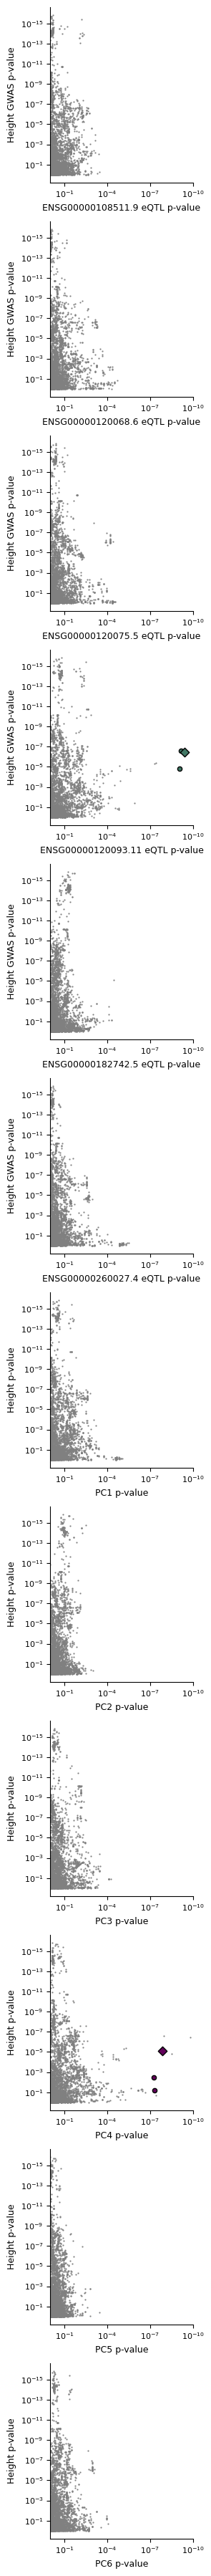

In [66]:
num_genes = len(example_cluster_id.split('_'))
n_gwas = len(example_gwas_traits)
min_pval = min(nominal_e['pval_nominal'].min(), nominal_pc['pval_nominal'].min())
rounded_min_pval = 10 ** round(math.log10(min_pval))

fig, ax = plt.subplots(ncols=n_gwas, nrows=num_genes*2, figsize=(3*n_gwas, 6*num_genes))

if n_gwas == 1:
    ax = np.array(ax).reshape((num_genes*2, 1))

gene_ids = example_cluster_id.split('_')

for gwas_trait_idx in range(n_gwas):
    for i, gene_id in enumerate(gene_ids):
        plot_egene_coloc(
            ax[i, gwas_trait_idx], 
            gene_id, 
            gene_id, 
            nominal_e, 
            gwas_data[gwas_trait_idx], 
            gwas_names[gwas_trait_idx], 
            plot_example_cs=False
        )
    for i, gene_id in enumerate(gene_ids):
        plot_pcgene_coloc(
            ax[i+num_genes, gwas_trait_idx], 
            i+1, 
            nominal_pc, 
            gwas_data[gwas_trait_idx], 
            gwas_names[gwas_trait_idx], 
            plot_example_cs=False
        )

# Set all x-axis limits to (1, rounded_min_pval) for each subplot axis
for axes in ax.flatten():
    axes.set_xlim(1, rounded_min_pval)

plt.tight_layout()
plt.savefig(f"{config['working_dir']}/workflow/supplemental_figures/figures/figure_s12_c.pdf", 
            transparent=True, bbox_inches='tight', dpi=300)
plt.show()

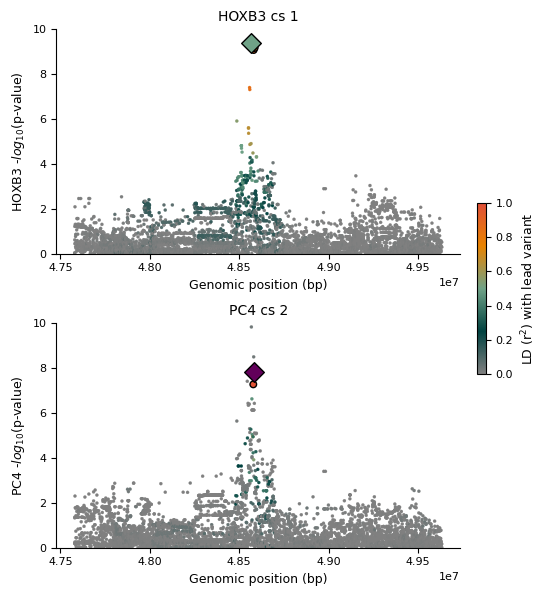

In [55]:
example_cluster_cs = susie_annotated[susie_annotated['phenotype_id'].str.contains(example_cluster_id)]

fig, ax = plt.subplots(figsize=(5, 3*example_cluster_cs['cs_id'].nunique()), nrows=example_cluster_cs['cs_id'].nunique(), ncols=1)

# Make a locuszoom for each credible set
for i, cs_id in enumerate(example_cluster_cs['cs_id'].unique()):
    if '_e_' in cs_id:
        cs_nominal = nominal_e[nominal_e['phenotype_id'] == cs_id.split('_cs')[0]].copy()
        lead_var_color = qtl_palette['eQTL only']
        pheno_label = get_gene_name(cs_id.split('_e_')[-1].split('_cs')[0], config) + '_cs' + cs_id.split('_cs')[-1]
    else:
        cs_nominal = nominal_pc[nominal_pc['phenotype_id'] == cs_id.split('_cs')[0]].copy()
        lead_var_color = qtl_palette['pcQTL only']
        pheno_label = 'PC' + cs_id.split('_pc')[-1]

    cs_susie = susie_annotated[susie_annotated['cs_id'] == cs_id]
    cs_variant_ids = cs_susie['variant_id'].unique()
    lead_variant_id = cs_susie[cs_susie['pip'] == cs_susie['pip'].max()]['variant_id'].values[0]

    cs_nominal['in_cs'] = cs_nominal['variant_id'].isin(cs_variant_ids)
    cs_nominal['pos'] = cs_nominal['variant_id'].str.split('_').str[1].astype(int)

    # Compute LD with lead variant if available
    if lead_variant_id is not None and lead_variant_id in ld.index:
        ld_with_lead = ld.loc[lead_variant_id]
        cs_nominal = cs_nominal.set_index('variant_id')
        cs_nominal['ld_with_lead'] = ld_with_lead[cs_nominal.index].values ** 2
        cs_nominal = cs_nominal.reset_index()

    # Plot
    sns.scatterplot(
        data=cs_nominal, 
        x='pos', 
        y=-np.log10(cs_nominal['pval_nominal']), 
        hue='ld_with_lead', 
        palette=ld_palette, 
        edgecolor=None, 
        legend=False,
        s=5,
        alpha=1, 
        ax=ax[i], 
        hue_norm=ld_norm
    )
    if len(cs_susie) > 1:
        # Highlight credible set variants
        sns.scatterplot(
            data=cs_nominal[cs_nominal['in_cs']],
            x='pos',
            y=-np.log10(cs_nominal[cs_nominal['in_cs']]['pval_nominal']),
            hue='ld_with_lead', 
            palette=ld_palette, 
            marker='o',
            s=cs_susie['pip']*100,
            edgecolor='k',
            linewidth=1,
            alpha=1,
            ax=ax[i],
            legend=False, 
            hue_norm=ld_norm
        )  

    # Highlight lead variant
    sns.scatterplot(
        data=cs_nominal[cs_nominal['variant_id'] == lead_variant_id],
        x='pos',
        y=-np.log10(cs_nominal[cs_nominal['variant_id'] == lead_variant_id]['pval_nominal']),
        marker='D',
        color=lead_var_color,
        s=100,
        edgecolor='k',
        linewidth=1,
        alpha=1,
        ax=ax[i],
        legend=False
    )   
    ax[i].set_ylabel('{} '.format(pheno_label.split('_')[0]) + r'-$log_{10}$(p-value)')
    ax[i].set_xlabel('Genomic position (bp)')
    ax[i].set_title(pheno_label.replace('_', ' '))
    ax[i].spines['right'].set_visible(False)
    ax[i].spines['top'].set_visible(False)

# Set all x-axis limits to (1, rounded_min_pval) for each subplot axis
for axes in np.ravel(ax):
    axes.set_ylim(0, -np.log10(rounded_min_pval))

plt.tight_layout()

# Add the colorbar to the right of the last axis
sm = mpl.cm.ScalarMappable(cmap=ld_palette, norm=ld_norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='vertical', fraction=0.02, pad=0.04)
cbar.set_label('LD (r$^2$) with lead variant')

plt.savefig(f"{config['working_dir']}/workflow/supplemental_figures/figures/figure_s12_b.1.pdf", 
            transparent=True, bbox_inches='tight', dpi=300)
plt.show()  


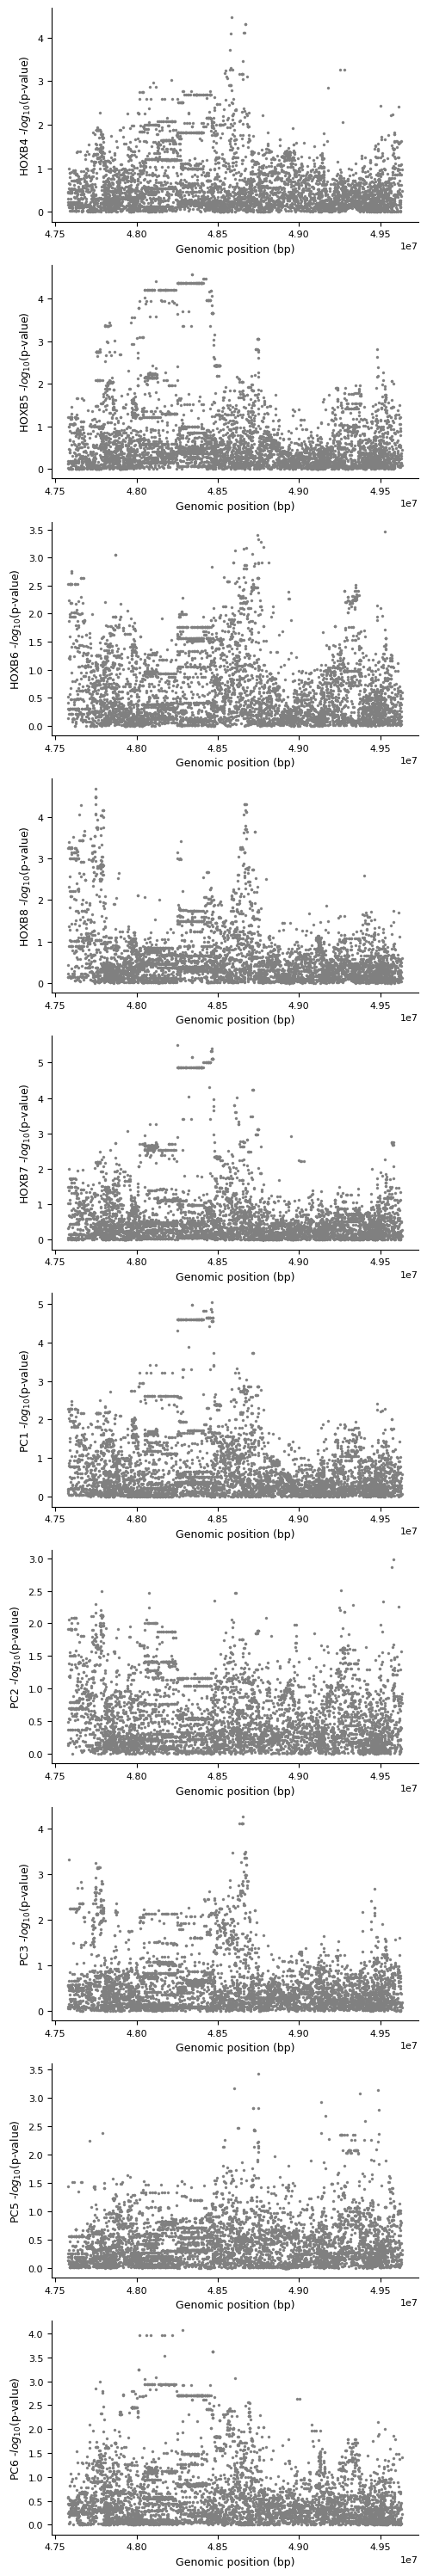

In [56]:
all_phenotypes = [*nominal_e['phenotype_id'].unique(), *nominal_pc['phenotype_id'].unique()]

no_cs_phenotypes = []
for phenotype in all_phenotypes:
    if not phenotype in example_cluster_cs['phenotype_id'].unique():
        no_cs_phenotypes.append(phenotype)


fig, ax = plt.subplots(
    figsize=(5, 3 * len(no_cs_phenotypes)),
    nrows=len(no_cs_phenotypes),
    ncols=1,
    squeeze=False
)

for i, pheno_id in enumerate(no_cs_phenotypes):
    # Determine if this is an eQTL or pcQTL phenotype
    if '_e_' in pheno_id:
        cs_nominal = nominal_e[nominal_e['phenotype_id'] == pheno_id].copy()
        pheno_label = get_gene_name(pheno_id.split('_e_')[-1], config)
    else:
        cs_nominal = nominal_pc[nominal_pc['phenotype_id'] == pheno_id].copy()
        pheno_label = 'PC' + pheno_id.split('_pc')[-1] if '_pc' in pheno_id else pheno_id

    # Add position column
    cs_nominal['pos'] = cs_nominal['variant_id'].str.split('_').str[1].astype(int)

    # Plot all variants for this phenotype, all points grey
    sns.scatterplot(
        data=cs_nominal,
        x='pos',
        y=-np.log10(cs_nominal['pval_nominal']),
        color='grey',
        edgecolor=None,
        legend=False,
        s=5,
        alpha=1,
        ax=ax[i, 0]
    )

    ax[i, 0].set_ylabel(f"{pheno_label} " + r"-$log_{10}$(p-value)")
    ax[i, 0].set_xlabel("Genomic position (bp)")
    ax[i, 0].spines['right'].set_visible(False)
    ax[i, 0].spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig(f"{config['working_dir']}/workflow/supplemental_figures/figures/figure_s12_b.2.pdf", 
            transparent=True, bbox_inches='tight', dpi=300)
plt.show()


gwas_id
GIANT_HEIGHT    [5, 7, 8, 9, 2, 1, 4, 3, 6]
Name: idx1, dtype: object

In [64]:
cluster_gwas_coloc

,gwas_id,qtl_id,nsnps,hit1,hit2,PP.H0.abf,PP.H1.abf,PP.H2.abf,PP.H3.abf,PP.H4.abf,idx1,idx2,gwas_cs_is,qtl_cs_is
2415,GIANT_HEIGHT,ENSG00000108511.9_ENSG00000120068.6_ENSG000001...,1160,chr17_48584210_C_T_b38,chr17_48583930_G_A_b38,2.474220e-51,0.000431,5.743579e-48,0.999522,0.000047,5,1,5,1
2416,GIANT_HEIGHT,ENSG00000108511.9_ENSG00000120068.6_ENSG000001...,1160,chr17_48533217_C_A_b38,chr17_48583930_G_A_b38,5.888088e-25,0.000431,1.366843e-21,0.999534,0.000035,7,1,7,1
2417,GIANT_HEIGHT,ENSG00000108511.9_ENSG00000120068.6_ENSG000001...,1160,chr17_49156755_T_G_b38,chr17_48583930_G_A_b38,7.105511e-07,0.000430,1.649452e-03,0.997888,0.000032,8,1,8,1
2418,GIANT_HEIGHT,ENSG00000108511.9_ENSG00000120068.6_ENSG000001...,1160,chr17_48602805_G_A_b38,chr17_48583930_G_A_b38,2.501106e-11,0.000431,5.805991e-08,0.999563,0.000007,9,1,9,1
2419,GIANT_HEIGHT,ENSG00000108511.9_ENSG00000120068.6_ENSG000001...,1160,chr17_49352472_A_G_b38,chr17_48583930_G_A_b38,1.352685e-11,0.000431,3.140082e-08,0.999479,0.000090,2,1,2,1
2420,GIANT_HEIGHT,ENSG00000108511.9_ENSG00000120068.6_ENSG000001...,1160,chr17_48897372_T_C_b38,chr17_48583930_G_A_b38,1.790866e-15,0.000431,4.157261e-12,0.999560,0.000009,1,1,1,1
2421,GIANT_HEIGHT,ENSG00000108511.9_ENSG00000120068.6_ENSG000001...,1160,chr17_47944699_G_A_b38,chr17_48583930_G_A_b38,1.121551e-05,0.000419,2.603535e-02,0.973241,0.000293,4,1,4,1
2422,GIANT_HEIGHT,ENSG00000108511.9_ENSG00000120068.6_ENSG000001...,1160,chr17_48018910_C_T_b38,chr17_48583930_G_A_b38,2.783279e-06,0.000428,6.461018e-03,0.992918,0.000190,3,1,3,1
2423,GIANT_HEIGHT,ENSG00000108511.9_ENSG00000120068.6_ENSG000001...,1160,chr17_47698964_T_G_b38,chr17_48583930_G_A_b38,9.639808e-07,0.000430,2.237755e-03,0.997252,0.000080,6,1,6,1
2424,GIANT_HEIGHT,ENSG00000108511.9_ENSG00000120068.6_ENSG000001...,1160,chr17_48584210_C_T_b38,chr17_48584210_C_T_b38,2.217776e-52,0.000039,1.154191e-50,0.000009,0.999953,5,2,5,2
